# TAE-IA · Module 6 · L10 — Image Captioning and Visual Understanding

| | |
|---|---|
| **Module** | 6 — Practical AI Applications: Images and Audio |
| **Lesson** | L10 |
| **Track** | A — Vision |
| **Estimated duration** | 2 hours |
| **GPU required** | T4 (Colab) |
| **Prerequisites** | L09 cleanup cell run |

## Learning objectives
By the end of this notebook you will be able to:
- [ ] Generate image captions with BLIP-2 and identify its failure modes by image type
- [ ] Run Visual Question Answering with the correct prompt format and probe model limits
- [ ] Perform zero-shot image classification with CLIP using natural language categories
- [ ] Articulate what BLIP-2 can and cannot reason about (perception vs. cultural knowledge)

## Important — Drive storage
BLIP-2 (`Salesforce/blip2-opt-2.7b`) downloads ~2.7 GB on first run (safetensors only). **Do not run the cleanup cell after this lesson** — BLIP-2 is reused in L11 and is the core model for final projects P1, P3, and P4.

---

## Cell 0 — Setup (always run this first)

> Mounts Drive, checks GPU, fixes seed.

In [ ]:
# ================================================================
# TAE-IA M6 · Standard Setup -- DO NOT MODIFY THIS CELL
# ================================================================
import os, sys, random, time, shutil
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

MODEL_CACHE = '/content/drive/MyDrive/TAE_IA_M6/models'   # persistent, survives sessions
LOCAL_CACHE = '/content/model_cache'                      # ephemeral, dies with the runtime
os.makedirs(MODEL_CACHE, exist_ok=True)
os.makedirs(LOCAL_CACHE, exist_ok=True)

# Clear any cache left by earlier course versions.
for _leftover in ('hub', 'xet'):
    _p = os.path.join(MODEL_CACHE, _leftover)
    if os.path.exists(_p):
        shutil.rmtree(_p)

# ----------------------------------------------------------------
# Model cache with automatic fallback
# ----------------------------------------------------------------
# Models are cached on Drive so they survive a session restart. A free
# Google account has only 15 GB, shared with Gmail and Photos, which is
# less than this course needs end to end. So when Drive has no room we
# cache on the runtime's own disk instead: the lab still runs, but that
# copy is deleted when the session ends.
#
# The choice is made per model, not once per notebook. A model already
# sitting on Drive keeps being read from Drive even when Drive is far
# too full to accept anything new.

DRIVE_HEADROOM_GB = 1.0    # never fill Drive to the last byte
SIZE_MARGIN       = 1.15   # temp files and metadata written during a download


def _free_gb(path):
    try:
        return shutil.disk_usage(path).free / 1e9
    except Exception:
        return 0.0


def _is_cached(path):
    """True if <path> holds anything but HuggingFace's incomplete-download folder."""
    return os.path.isdir(path) and any(e != '.cache' for e in os.listdir(path))


def _disk_full(exc):
    """ENOSPC, quota exceeded, or the I/O error drivefs raises when Drive is full."""
    return (getattr(exc, 'errno', None) in (28, 122, 5)
            or 'no space' in str(exc).lower()
            or 'quota' in str(exc).lower())


def cache_dir(name, needed_gb):
    """Return the directory model <name> should live in, preferring Drive."""
    drive_dir = os.path.join(MODEL_CACHE, name)
    local_dir = os.path.join(LOCAL_CACHE, name)

    if _is_cached(drive_dir):
        return drive_dir            # already on Drive: reading it costs no space
    if _is_cached(local_dir):
        return local_dir            # already fell back earlier this session

    required = needed_gb * SIZE_MARGIN + DRIVE_HEADROOM_GB
    free = _free_gb(MODEL_CACHE)
    if free >= required:
        os.makedirs(drive_dir, exist_ok=True)
        print(f'[cache] {name} -> Drive ({needed_gb:.2f} GB needed, {free:.1f} GB free).')
        return drive_dir

    local_free = _free_gb('/content')
    if local_free < required:
        raise RuntimeError(
            f'{name} needs ~{needed_gb:.1f} GB, but only {free:.1f} GB is free on '
            f'Drive and {local_free:.1f} GB on the runtime disk.\n'
            f'Free space in Google Drive (delete unused TAE_IA_M6/models subfolders) '
            f'and re-run this cell.')

    os.makedirs(local_dir, exist_ok=True)
    print(f'[cache] Not enough room on Drive for {name}: needs {needed_gb:.2f} GB\n'
          f'        plus margin, {free:.1f} GB free. Caching on the runtime instead.\n'
          f'        The lab runs normally, but this copy is deleted when the session\n'
          f'        ends and downloads again next time. Free space in Drive to avoid\n'
          f'        the repeat download.')
    return local_dir


def cached_fetch(name, needed_gb, download):
    """Run download(target_dir) in the best available cache and return its result.

    Retries on the runtime disk if Drive fills up mid-download: a pre-flight
    space check cannot catch a quota that runs out halfway through.
    """
    target = cache_dir(name, needed_gb)
    try:
        return download(target)
    except OSError as e:
        if not _disk_full(e) or target.startswith(LOCAL_CACHE):
            raise
        print(f'[cache] Drive ran out of room mid-download ({e}).\n'
              f'        Discarding the partial copy and retrying on the runtime disk.')
        shutil.rmtree(target, ignore_errors=True)
        fallback = os.path.join(LOCAL_CACHE, name)
        os.makedirs(fallback, exist_ok=True)
        return download(fallback)


def cached_snapshot(name, repo_id, needed_gb, **kwargs):
    """snapshot_download into the best available cache, returning its path."""
    from huggingface_hub import snapshot_download

    def _dl(target):
        snapshot_download(repo_id, local_dir=target, **kwargs)
        return target

    return cached_fetch(name, needed_gb, _dl)


_drive_free = _free_gb(MODEL_CACHE)
print(f'Model cache: {MODEL_CACHE}  ({_drive_free:.1f} GB free on Drive)')
if _drive_free < 1.0:
    print('WARNING: under 1 GB free on Drive. Models will cache on the runtime,\n'
          '         but saving your lab outputs may fail. Free space in Drive.')

import torch
if not torch.cuda.is_available():
    print('\nNo GPU detected. Go to: Runtime > Change runtime type > T4 GPU')
    raise SystemExit('GPU required.')

gpu_name = torch.cuda.get_device_name(0)
vram_gb  = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f'GPU: {gpu_name}  |  VRAM: {vram_gb:.1f} GB')

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
print(f'Fixed seed: {SEED}')
print(f'Python {sys.version.split()[0]}  |  PyTorch {torch.__version__}')

Mounted at /content/drive
Model cache: /content/drive/MyDrive/TAE_IA_M6/models  (66.8 GB free on Drive)
GPU: Tesla T4  |  VRAM: 15.6 GB
Fixed seed: 42
Python 3.13.15  |  PyTorch 2.11.0+cu128


In [ ]:
# ================================================================
# Install dependencies for L10
# ================================================================
!pip install transformers accelerate Pillow requests -q

import transformers
print(f'transformers {transformers.__version__}')

transformers 5.15.1


---
## Part 1 — Context and Key Concepts

> Read this before running any code.

### BLIP-2: Q-Former architecture

BLIP-2 solves the vision-language gap with a three-part design:

1. **Frozen ViT-L image encoder** — converts the image into 257 feature tokens (one per 14×14 patch + class token)
2. **Trainable Q-Former** — a small transformer with 32 learned query tokens. These queries attend to the 257 image tokens via cross-attention, extracting the most task-relevant visual information into 32 compact representations
3. **Frozen LLM (OPT-2.7B)** — the 32 Q-Former outputs are projected into the LLM's token space and prepended to the text prompt. The LLM then generates text conditioned on both visual and text inputs

Only the Q-Former (≈107M params) is trained. The image encoder and LLM are frozen, which makes BLIP-2 efficient to train and prevents catastrophic forgetting of either modality.

### VQA prompt format

BLIP-2 uses a strict prompt format for VQA:
```
"Question: <your question> Answer:"
```
The model generates tokens after `"Answer:"`. Using a different format (e.g., omitting the prefix) often produces degraded or off-topic responses.

### CLIP: contrastive vision-language alignment

CLIP's image encoder and text encoder are trained together so that matching image-text pairs have high cosine similarity and non-matching pairs have low similarity. At inference, zero-shot classification works by encoding the image and all candidate category strings, then selecting the category with highest similarity score — no task-specific fine-tuning needed.

---

## Part 2 — Lab

### Section 2.0 — Load BLIP-2

In [ ]:
# Section 2.0 — Load BLIP-2
# First run: downloads ~2.7 GB to Drive (safetensors only; subsequent runs load from cache)
from transformers import Blip2Processor, Blip2ForConditionalGeneration
import torch

BLIP2_MODEL = 'Salesforce/blip2-opt-2.7b'

# Not gated. Repo carries duplicate weights (safetensors + pytorch .bin) --
# safetensors only cuts the download roughly in half.
BLIP2_DIR = cached_snapshot(
    'blip2-opt-2.7b-local',
    BLIP2_MODEL,
    needed_gb=14.98,
    allow_patterns=["*.json", "*.txt", "*.safetensors"],
)

print(f'Loading {BLIP2_MODEL}...')
t0        = time.time()
processor = Blip2Processor.from_pretrained(BLIP2_DIR)
model     = Blip2ForConditionalGeneration.from_pretrained(
    BLIP2_DIR,
    torch_dtype=torch.float16,
    device_map='auto'          # automatically places layers across GPU + RAM
)
model.eval()
print(f'Loaded in {time.time()-t0:.0f}s')

OUTPUT_DIR = '/content/drive/MyDrive/TAE_IA_M6/L10_output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

[cache] blip2-opt-2.7b-local -> Drive (14.98 GB needed, 66.7 GB free).


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

Loading Salesforce/blip2-opt-2.7b...


Loading weights:   0%|          | 0/1247 [00:00<?, ?it/s]

Loaded in 75s


In [ ]:
# Section 2.0 (cont.) — Helper functions
from PIL import Image
from io import BytesIO
import requests

def blip2_caption(pil_image, max_new_tokens=60):
    """Generate an unconditional caption."""
    inputs = processor(images=pil_image, return_tensors='pt').to('cuda', torch.float16)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=max_new_tokens)
    return processor.decode(out[0], skip_special_tokens=True).strip()

def blip2_vqa(pil_image, question, max_new_tokens=30):
    """Answer a question about an image. Use 'Question: ... Answer:' format."""
    if not question.startswith('Question:'):
        question = f'Question: {question} Answer:'
    inputs = processor(
        images=pil_image, text=question, return_tensors='pt'
    ).to('cuda', torch.float16)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=max_new_tokens)
    full = processor.decode(out[0], skip_special_tokens=True).strip()
    # Return only the answer portion (after 'Answer:')
    return full.split('Answer:')[-1].strip() if 'Answer:' in full else full

# Wikimedia rejects the default requests User-Agent with 403, so every fetch
# has to identify itself. It also only serves a fixed set of thumbnail widths
# (20/40/60/120/250/330/500/960/1280/1920/3840) -- any other width returns 400.
WIKI_UA = {'User-Agent': 'TAE-IA-M6-course/1.0 (classroom use; contact instructor)'}

def load_url(url, size=None):
    """Download an image. Raises on failure -- a silent placeholder here would
    quietly invalidate every caption, VQA answer and CLIP score below."""
    r = requests.get(url, timeout=20, headers=WIKI_UA)
    r.raise_for_status()
    img = Image.open(BytesIO(r.content)).convert('RGB')
    if size:
        img = img.resize(size, Image.LANCZOS)
    return img

print('Helper functions ready.')

Helper functions ready.


### Section 2.1 — Prepare test images

landscape: (400, 300)
animal: (400, 300)
food: (400, 300)
urban: (400, 300)
art: (400, 300)
document: (400, 200)
chart: (400, 240)
meme: (400, 200)


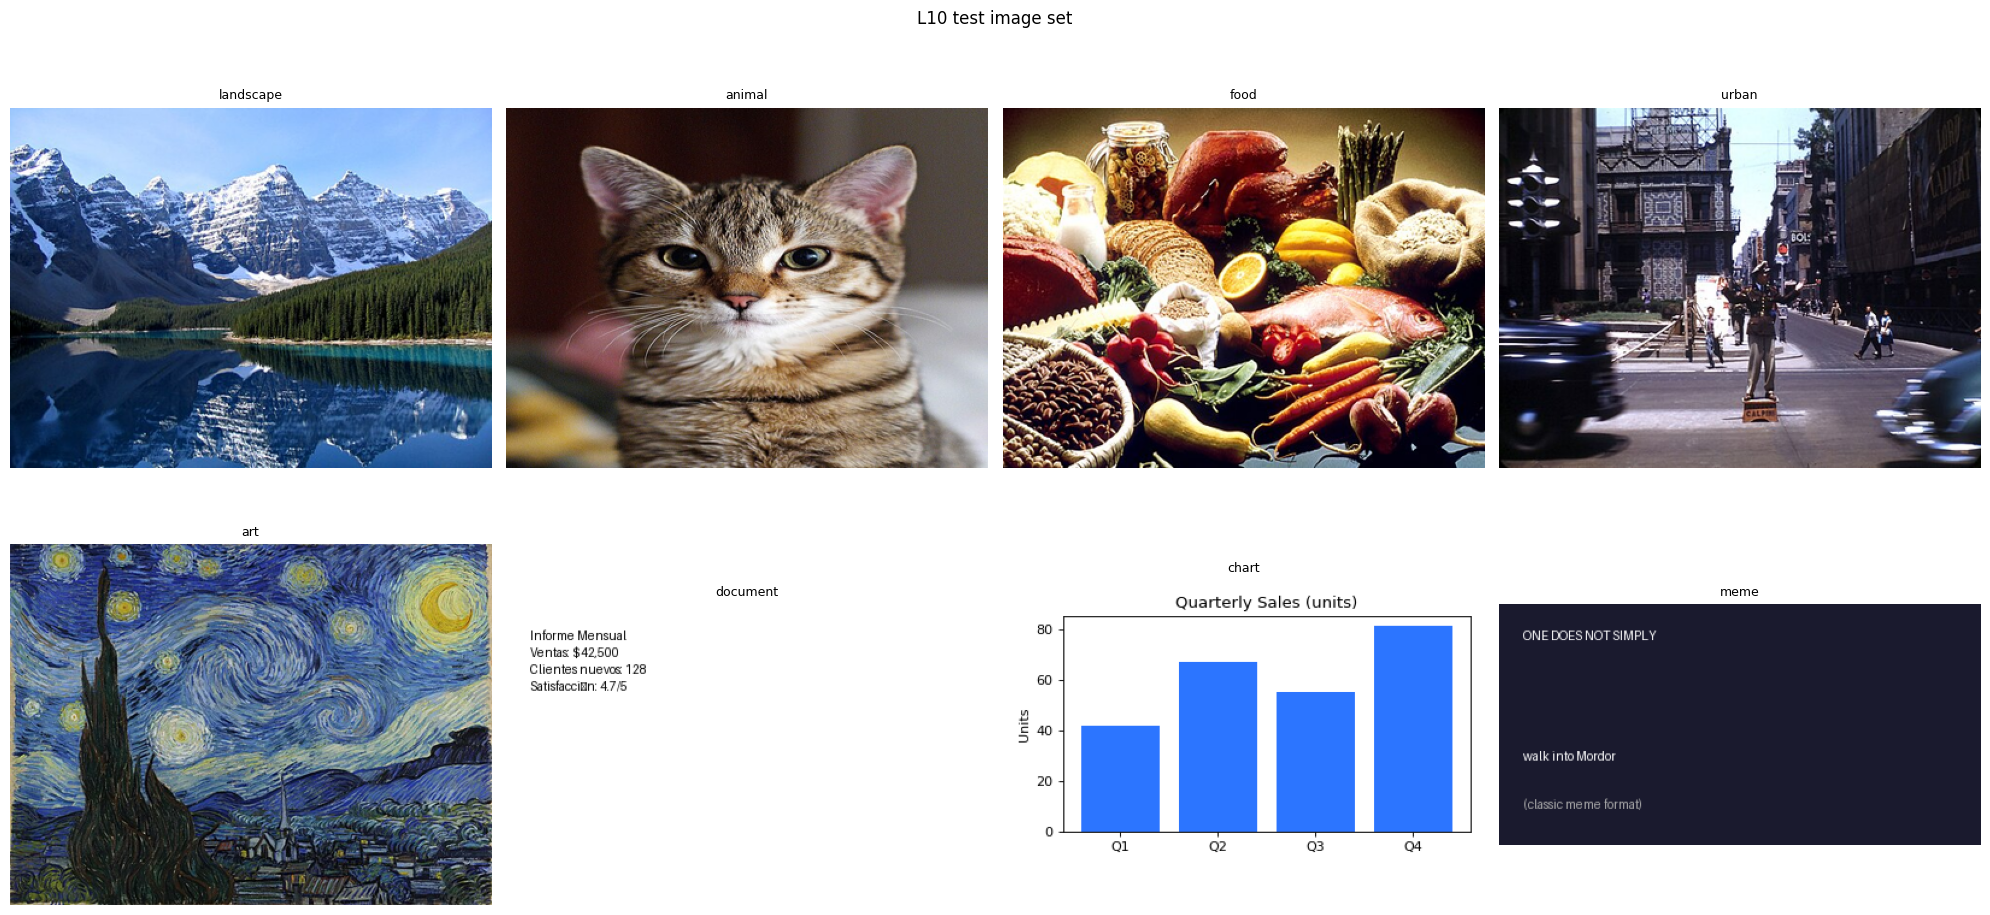

In [ ]:
# Section 2.1 (cont.) — Load 8 diverse test images
# All images are public domain from Wikimedia Commons
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
import time
import requests
from io import BytesIO

_WM = 'https://upload.wikimedia.org/wikipedia/commons/thumb'

# Each key is the image *category* the caption will be judged against, so the
# picture actually has to be that category -- see Part 4.1.
IMAGE_SOURCES = {
    'landscape':    f'{_WM}/c/c5/Moraine_Lake_17092005.jpg/500px-Moraine_Lake_17092005.jpg',
    'animal':       f'{_WM}/1/14/Gatto_europeo4.jpg/500px-Gatto_europeo4.jpg',
    'food':         f'{_WM}/6/6d/Good_Food_Display_-_NCI_Visuals_Online.jpg/500px-Good_Food_Display_-_NCI_Visuals_Online.jpg',
    'urban':        f'{_WM}/f/f6/Mexico_City_traffic_cop.jpg/500px-Mexico_City_traffic_cop.jpg',
    'art':          f'{_WM}/e/ea/Van_Gogh_-_Starry_Night_-_Google_Art_Project.jpg/500px-Van_Gogh_-_Starry_Night_-_Google_Art_Project.jpg',
    'document':     None,   # generated locally
    'chart':        None,   # generated locally
    'meme':         None,   # generated locally
}

def load_url(url, size=None, max_retries=5):
    """Descarga una imagen con User-Agent identificable y reintentos con backoff."""
    headers = {
        'User-Agent': 'Mozilla/5.0 (compatible; TAE-IA-notebook/1.0; educational use)'
    }
    for attempt in range(max_retries):
        resp = requests.get(url, headers=headers, timeout=15)
        if resp.status_code == 429:
            wait = 5 * (attempt + 1)  # backoff creciente: 5, 10, 15, 20, 25s
            print(f'429 recibido, esperando {wait}s antes de reintentar...')
            time.sleep(wait)
            continue
        resp.raise_for_status()
        img = Image.open(BytesIO(resp.content)).convert('RGB')
        if size is not None:
            img = img.resize(size)
        return img
    raise RuntimeError(f'No se pudo descargar {url} tras {max_retries} intentos')

def make_text_image(text, size=(400, 200), bg='white', fg='black', font_size=24):
    img  = Image.new('RGB', size, bg)
    draw = ImageDraw.Draw(img)
    try:
        font = ImageFont.truetype('/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf', font_size)
    except Exception:
        font = ImageFont.load_default()
    draw.multiline_text((20, 20), text, font=font, fill=fg)
    return img

def make_bar_chart_image():
    fig, ax = plt.subplots(figsize=(5, 3))
    ax.bar(['Q1', 'Q2', 'Q3', 'Q4'], [42, 67, 55, 81], color=['#2C75FF']*4)
    ax.set_title('Quarterly Sales (units)'); ax.set_ylabel('Units')
    plt.tight_layout()
    buf = BytesIO(); plt.savefig(buf, format='PNG', dpi=80); plt.close()
    buf.seek(0); return Image.open(buf).convert('RGB')

def make_meme_image():
    base = Image.new('RGB', (400, 200), '#1a1a2e')
    draw = ImageDraw.Draw(base)
    try:
        font_big = ImageFont.truetype('/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf', 28)
        font_sm  = ImageFont.truetype('/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf', 18)
    except Exception:
        font_big = font_sm = ImageFont.load_default()
    draw.text((20,  20), 'ONE DOES NOT SIMPLY', font=font_big, fill='white')
    draw.text((20, 120), 'walk into Mordor', font=font_big, fill='white')
    draw.text((20, 160), '(classic meme format)', font=font_sm,  fill='#aaaaaa')
    return base

# Build image dict
images = {}
for name, url in IMAGE_SOURCES.items():
    if url is not None:
        images[name] = load_url(url, size=(400, 300))
        time.sleep(5)  # margen entre descargas para evitar 429
    elif name == 'document':
        images[name] = make_text_image(
            'Informe Mensual\nVentas: $42,500\nClientes nuevos: 128\nSatisfacción: 4.7/5')
    elif name == 'chart':
        images[name] = make_bar_chart_image()
    elif name == 'meme':
        images[name] = make_meme_image()
    print(f'{name}: {images[name].size}')

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for ax, (name, img) in zip(axes.flatten(), images.items()):
    ax.imshow(img); ax.set_title(name, fontsize=9); ax.axis('off')
plt.suptitle('L10 test image set', fontsize=12)
plt.tight_layout()
plt.show()

### Section 2.2 — BLIP-2 captioning across 8 image types

Image type      |  Time | Caption
------------------------------------------------------------------------------------------
landscape       |  2.5s | moraine lake, banff national park, alberta, canada
animal          |  0.2s | a cat sitting on a bed
food            |  0.4s | a variety of food items including meat, vegetables, and fruit
urban           |  0.5s | a man in a suit standing on a box in the middle of a city street
art             |  0.3s | the starry night by vincent van gogh
document        |  0.4s | informe mercantil vendita $ 2,000
chart           |  0.4s | a bar chart showing the number of sales units in the quarter
meme            |  0.3s | one does not simply walk into the moor


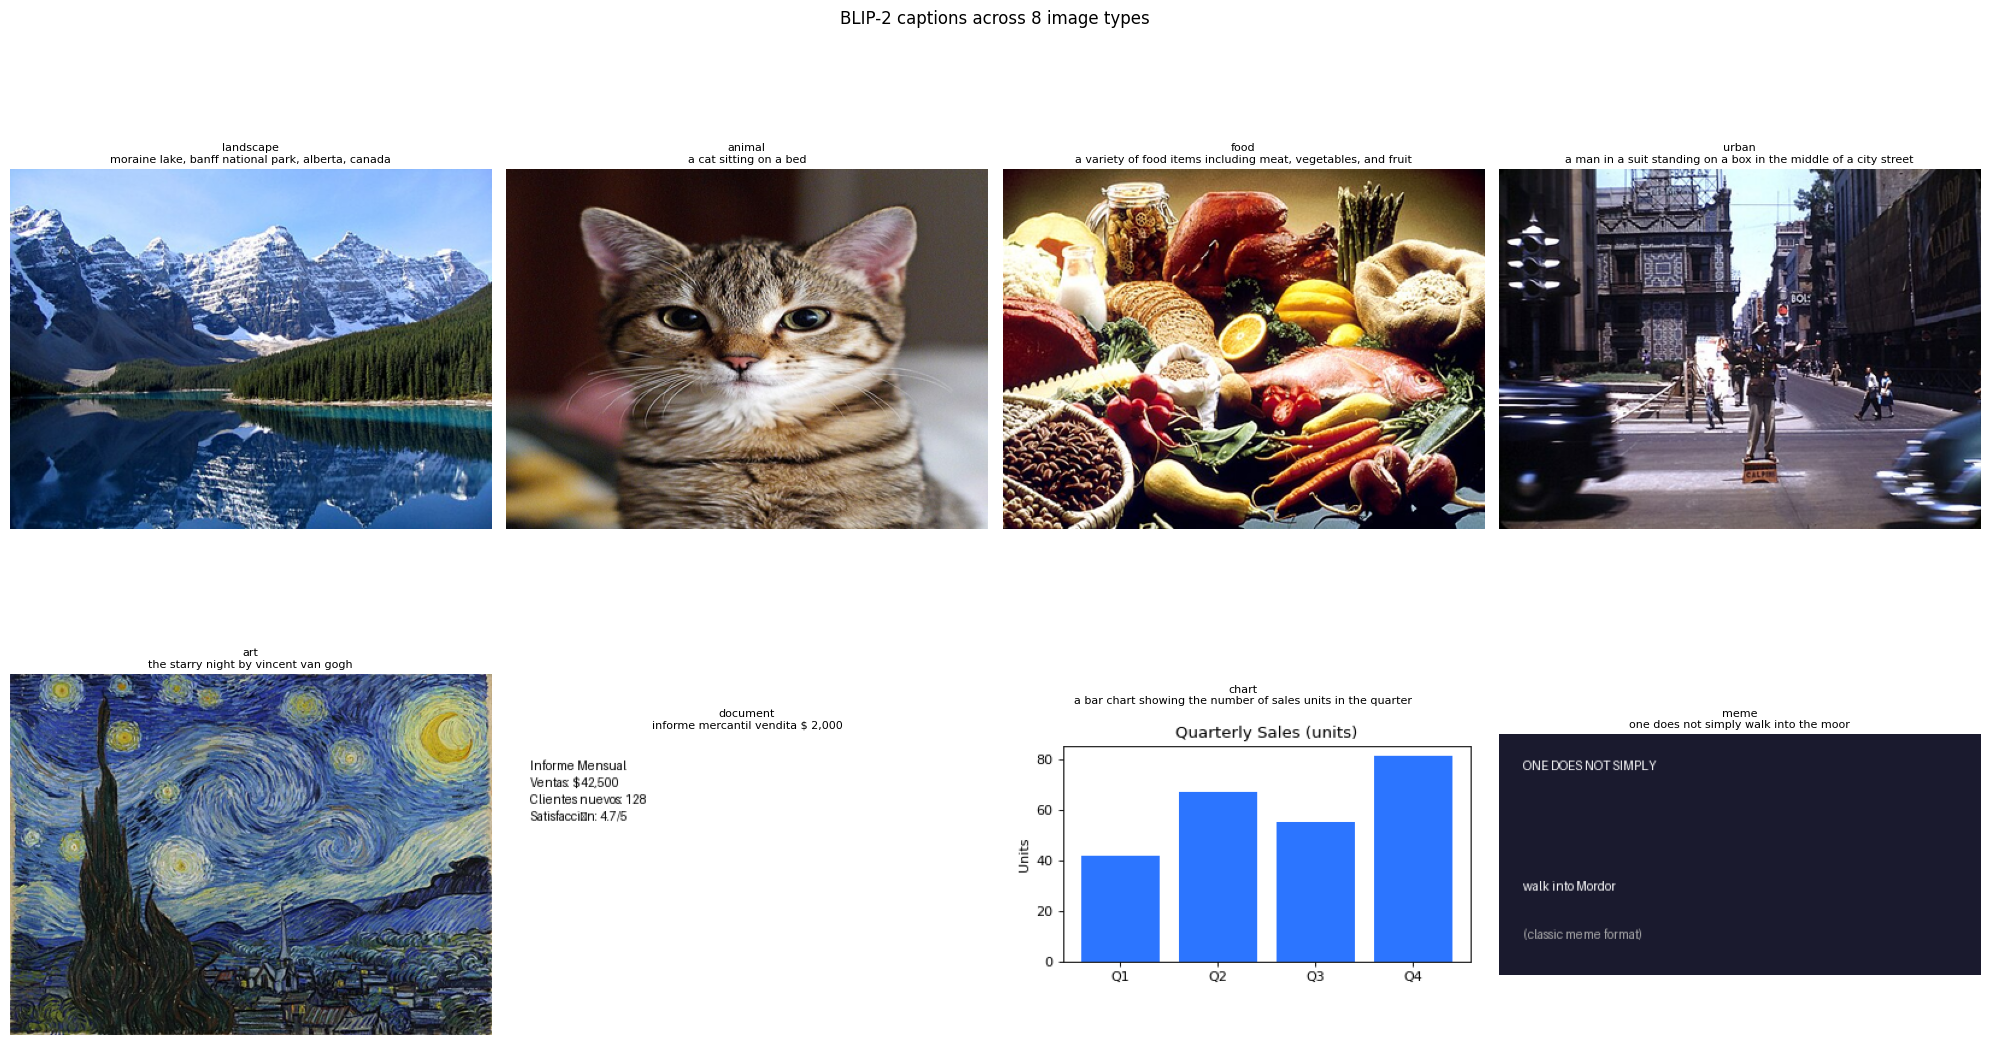

In [ ]:
# Section 2.2 — Generate captions for all 8 images
captions = {}
print(f"{'Image type':<15} | {'Time':>5} | Caption")
print('-' * 90)

for name, img in images.items():
    t0           = time.time()
    caption      = blip2_caption(img)
    t            = time.time() - t0
    captions[name] = caption
    print(f"{name:<15} | {t:>4.1f}s | {caption}")

# Display all images with captions
fig, axes = plt.subplots(2, 4, figsize=(20, 12))
for ax, (name, img) in zip(axes.flatten(), images.items()):
    ax.imshow(img)
    ax.set_title(f"{name}\n{captions[name]}", fontsize=8, wrap=True)
    ax.axis('off')
plt.suptitle('BLIP-2 captions across 8 image types', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'captioning_grid.png'), dpi=80)
plt.show()

**What do you observe?**  
- Which image types received the most accurate captions?
- Did the model read any text visible in the document or meme images?
- Which caption was most generic or could apply to many images?

*Write your observation here (rank image types from best to worst captioning quality):*

(double-click to edit)

### Section 2.3 — VQA: systematic question probing

In [ ]:
# Section 2.3 — VQA with 5 question types on 3 selected images
# Select images with interesting ground truth for analysis
vqa_images = {
    'animal':   images['animal'],
    'chart':    images['chart'],
    'document': images['document'],
}

questions = [
    'What is the main subject of this image?',
    'What colors are most prominent in this image?',
    'How many distinct objects can you count in this image?',
    'Is there any text visible in this image? If so, what does it say?',
    'What would be a good title or label for this image?',
]

print('VQA results\n' + '=' * 90)
vqa_results = {}
for img_name, img in vqa_images.items():
    print(f"\n--- {img_name.upper()} ---")
    vqa_results[img_name] = {}
    for q in questions:
        answer = blip2_vqa(img, q)
        vqa_results[img_name][q] = answer
        print(f"  Q: {q}")
        print(f"  A: {answer}\n")

VQA results

--- ANIMAL ---
  Q: What is the main subject of this image?
  A: The cat

  Q: What colors are most prominent in this image?
  A: The cat's eyes

  Q: How many distinct objects can you count in this image?
  A: 1

  Q: Is there any text visible in this image? If so, what does it say?
  A: No

  Q: What would be a good title or label for this image?
  A: "cat"


--- CHART ---
  Q: What is the main subject of this image?
  A: Quarterly sales units

  Q: What colors are most prominent in this image?
  A: The color of the bar graph

  Q: How many distinct objects can you count in this image?
  A: 1

  Q: Is there any text visible in this image? If so, what does it say?
  A: Yes, there is text visible in this image. If so, what does it say?

  Q: What would be a good title or label for this image?
  A: Quarterly sales units


--- DOCUMENT ---
  Q: What is the main subject of this image?
  A: informe mercantil

  Q: What colors are most prominent in this image?
  A: 

  Q: How m

 N circles | BLIP-2 answer
----------------------------------------
         2 | 3
         5 | There are four circles in this image
        10 | There are 6 circles in this image
        20 | There are 6 circles in this image


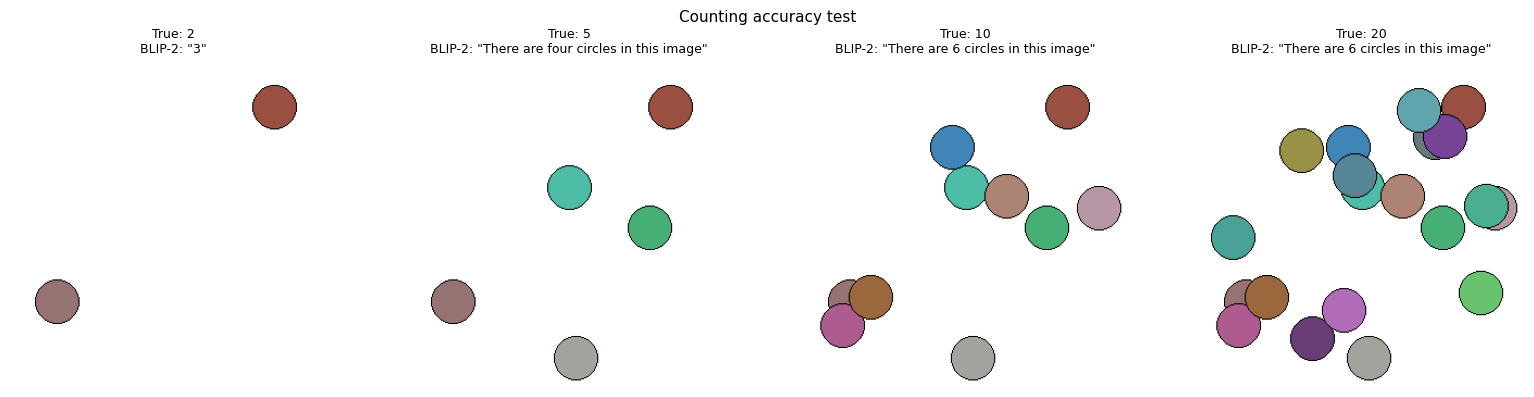

In [ ]:
# Section 2.3 (cont.) — Counting stress test
# Create images with a known number of objects and test counting accuracy

def make_counting_image(n_circles, size=300):
    from PIL import ImageDraw
    img  = Image.new('RGB', (size, size), 'white')
    draw = ImageDraw.Draw(img)
    rng  = np.random.default_rng(42)
    r    = 20
    for _ in range(n_circles):
        x = int(rng.integers(r, size - r))
        y = int(rng.integers(r, size - r))
        color = tuple(rng.integers(50, 200, 3).tolist())
        draw.ellipse([x-r, y-r, x+r, y+r], fill=color, outline='black')
    return img

count_tests = {n: make_counting_image(n) for n in [2, 5, 10, 20]}

print(f"{'N circles':>10} | {'BLIP-2 answer'}")
print('-' * 40)
for n, img in count_tests.items():
    answer = blip2_vqa(img, 'How many circles are in this image?')
    print(f"{n:>10} | {answer}")

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (n, img) in zip(axes, count_tests.items()):
    answer = blip2_vqa(img, 'How many circles are in this image?')
    ax.imshow(img); ax.set_title(f'True: {n}\nBLIP-2: "{answer}"', fontsize=9); ax.axis('off')
plt.suptitle('Counting accuracy test', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'vqa_counting.png'), dpi=100)
plt.show()

**What do you observe?**  
- At what count does BLIP-2 start giving wrong answers?
- For the document image, did the VQA correctly read any of the Spanish text?
- Which question type (subject, color, count, text, title) was most reliably answered?

*Write your observation here (include specific right/wrong answers from the VQA output):*

(double-click to edit)

### Section 2.4 — CLIP zero-shot classification

In [ ]:
# Section 2.4 — Load CLIP
import gc
from transformers import CLIPProcessor, CLIPModel

CLIP_MODEL = 'openai/clip-vit-base-patch32'

# Not gated. Repo has no safetensors file -- only pytorch_model.bin, plus
# flax/tf duplicates we don't need. Skip those to cut the download roughly in third.
CLIP_DIR = cached_snapshot(
    'clip-vit-base-patch32-local',
    CLIP_MODEL,
    needed_gb=0.61,
    allow_patterns=["*.json", "*.txt", "pytorch_model.bin"],
)

clip_proc  = CLIPProcessor.from_pretrained(CLIP_DIR)
clip_model = CLIPModel.from_pretrained(CLIP_DIR).to('cuda')
clip_model.eval()
print(f'CLIP loaded: {CLIP_MODEL}')

def clip_classify(pil_image, categories):
    """Return dict of {category: probability} sorted descending."""
    inputs = clip_proc(
        text=[f'a photo of {c}' for c in categories],
        images=pil_image,
        return_tensors='pt',
        padding=True
    ).to('cuda')
    with torch.no_grad():
        logits = clip_model(**inputs).logits_per_image
    probs = logits.softmax(dim=1).squeeze().cpu().tolist()
    result = dict(zip(categories, probs))
    return dict(sorted(result.items(), key=lambda x: -x[1]))

[cache] clip-vit-base-patch32-local -> Drive (0.61 GB needed, 57.2 GB free).


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIP loaded: openai/clip-vit-base-patch32


Image        | Top-1 prediction          |  Conf | Top-2                     |  Conf
-------------------------------------------------------------------------------------
landscape    | a landscape               | 94.3% | a painting or artwork     | 4.2%
animal       | a cat                     | 94.4% | a meme                    | 4.7%
food         | a display of food         | 100.0% | a painting or artwork     | 0.0%
urban        | a city street             | 98.8% | a landscape               | 0.5%
art          | a painting or artwork     | 94.9% | a landscape               | 4.0%
document     | a bar chart or graph      | 65.8% | a document with text      | 13.3%
chart        | a bar chart or graph      | 100.0% | a meme                    | 0.0%
meme         | a meme                    | 51.9% | a document with text      | 23.3%


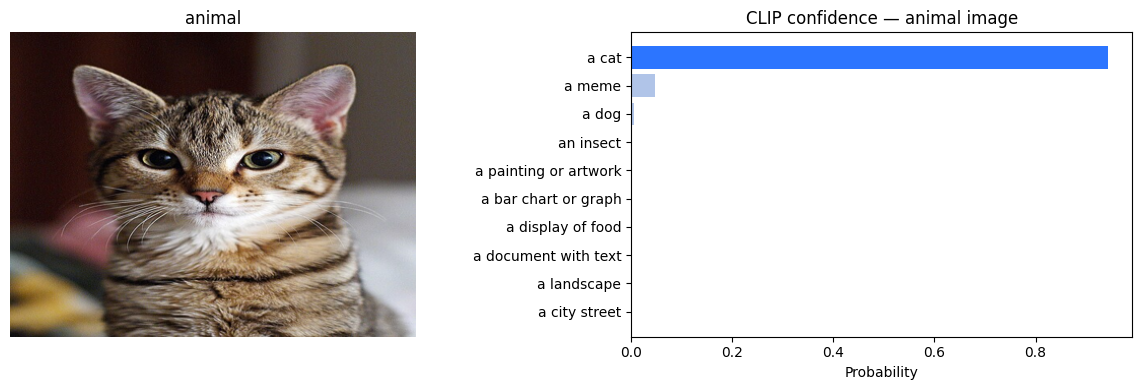

In [ ]:
# Section 2.4 (cont.) — Zero-shot classification on all 8 images
CATEGORIES_10 = [
    'a cat', 'a dog', 'a landscape', 'a display of food',
    'a painting or artwork', 'a document with text',
    'a bar chart or graph', 'a meme', 'a city street', 'an insect'
]

print(f"{'Image':<12} | {'Top-1 prediction':<25} | {'Conf':>5} | {'Top-2':<25} | {'Conf':>5}")
print('-' * 85)

clip_results = {}
for name, img in images.items():
    probs        = clip_classify(img, CATEGORIES_10)
    clip_results[name] = probs
    items        = list(probs.items())
    top1, p1     = items[0]
    top2, p2     = items[1]
    print(f"{name:<12} | {top1:<25} | {p1:>4.1%} | {top2:<25} | {p2:>4.1%}")

# Visualise confidence bars for the animal image
focus_img  = images['animal']
focus_probs = clip_results['animal']

fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(12, 4))
ax_img.imshow(focus_img); ax_img.set_title('animal'); ax_img.axis('off')
cats  = list(focus_probs.keys())
probs_list = list(focus_probs.values())
colors = ['#2C75FF' if i == 0 else '#b0c4e8' for i in range(len(cats))]
ax_bar.barh(cats, probs_list, color=colors)
ax_bar.set_xlabel('Probability'); ax_bar.set_title('CLIP confidence — animal image')
ax_bar.invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'clip_confidence.png'), dpi=100)
plt.show()

In [ ]:
# Section 2.4 (cont.) — Custom category experiment
# Test CLIP with a fine-grained category set where errors are expected

FINE_GRAINED = [
    'a tabby cat', 'a black cat', 'a white cat',
    'a golden retriever', 'a labrador', 'a poodle',
    'a domestic rabbit', 'a hamster'
]

for name in ['animal']:
    probs = clip_classify(images[name], FINE_GRAINED)
    print(f"Fine-grained classification for '{name}':")
    for cat, p in list(probs.items())[:4]:
        print(f"  {cat:<25} {p:.1%}")

Fine-grained classification for 'animal':
  a tabby cat               98.4%
  a white cat               1.1%
  a black cat               0.2%
  a hamster                 0.1%


**What do you observe?**  
- Did CLIP correctly classify all 8 image types in the 10-category test?
- For which image did CLIP have the lowest confidence in the correct category?
- In the fine-grained test, did the top-1 prediction match the actual animal species?

*Write your observation here (include specific cases where CLIP failed or was overconfident):*

(double-click to edit)

### Section 2.5 — Curiosity experiment: BLIP-2 and the meme

Caption: one does not simply walk into the moor

Q: What does this image say?
A: One does not simply walk into the moron

Q: What is the joke or humor in this image?
A: The joke is that the man is walking in the middle of the road

Q: What is the cultural reference in this image?
A: One does not simply walk into Mordor

Q: Is this image funny? Why or why not?
A: This image is funny because it is a funny image.

Q: What movie or franchise is this meme referencing?
A: one does not simply walk into a movie theater



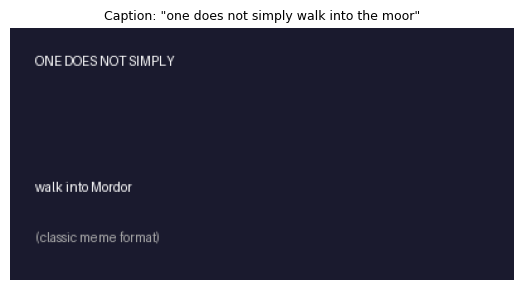

In [ ]:
# Section 2.5 — Meme comprehension experiment
meme = images['meme']

meme_questions = [
    'What does this image say?',
    'What is the joke or humor in this image?',
    'What is the cultural reference in this image?',
    'Is this image funny? Why or why not?',
    'What movie or franchise is this meme referencing?',
]

meme_caption = blip2_caption(meme)
print(f"Caption: {meme_caption}\n")

for q in meme_questions:
    a = blip2_vqa(meme, q)
    print(f"Q: {q}")
    print(f"A: {a}\n")

fig, ax = plt.subplots(figsize=(6, 3))
ax.imshow(meme); ax.set_title(f'Caption: "{meme_caption}"', fontsize=9); ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'meme_experiment.png'), dpi=100)
plt.show()

**What do you observe?**  
- Did BLIP-2 correctly read the text overlaid on the meme image?
- Did it identify the cultural reference (Lord of the Rings / Boromir)?
- What is the difference between *perceiving* the image content and *understanding* the joke?

*Write your observation here:*

(double-click to edit)

---
## Part 3 — Exercises

### Exercise 1 — Prompt engineering for VQA

**Task:** Ask the same factual question about the `chart` image (e.g., "What is the highest bar?") using three different phrasings. Does the phrasing change the answer? Try one phrasing that omits the `Question: ... Answer:` format and one that adds domain context (e.g., "In this bar chart of quarterly sales..."). Document which phrasing gives the most accurate answer.

**Expected output:** three questions + answers printed, with a written conclusion.

In [ ]:
# Exercise 1 -- VQA prompt engineering
# Remember: save any images to OUTPUT_DIR, e.g. img.save(os.path.join(OUTPUT_DIR, "exercise1.png"))
# ...
# Exercise 1 — Prompt engineering for VQA
# Asumiendo un modelo BLIP VQA (Salesforce/blip-vqa-base) vía transformers.
# Si ya tienes un pipeline/función VQA definido en el notebook, reemplaza
# la función `ask_vqa` de abajo por una llamada a ese pipeline y omite
# la carga del modelo.

from transformers import BlipProcessor, BlipForQuestionAnswering
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
_vqa_processor = BlipProcessor.from_pretrained('Salesforce/blip-vqa-base')
_vqa_model     = BlipForQuestionAnswering.from_pretrained('Salesforce/blip-vqa-base').to(device)

def ask_vqa(image, question):
    inputs = _vqa_processor(image, question, return_tensors='pt').to(device)
    out = _vqa_model.generate(**inputs, max_new_tokens=20)
    return _vqa_processor.decode(out[0], skip_special_tokens=True)

# Tres variantes de la misma pregunta factual sobre 'chart'
questions = {
    'formato Question/Answer':      'Question: What is the highest bar? Answer:',
    'pregunta directa (sin formato)': 'What is the highest bar?',
    'con contexto de dominio':       'In this bar chart of quarterly sales, which quarter has the highest bar?',
}

chart_img = images['chart']
results = {}
for label, q in questions.items():
    ans = ask_vqa(chart_img, q)
    results[label] = ans
    print(f'[{label}]')
    print(f'  Pregunta: {q}')
    print(f'  Respuesta: {ans}\n')

Loading weights:   0%|          | 0/788 [00:00<?, ?it/s]

[formato Question/Answer]
  Pregunta: Question: What is the highest bar? Answer:
  Respuesta: 95

[pregunta directa (sin formato)]
  Pregunta: What is the highest bar?
  Respuesta: blue

[con contexto de dominio]
  Pregunta: In this bar chart of quarterly sales, which quarter has the highest bar?
  Respuesta: all



*Does phrasing change BLIP-2's answer? Which format gave the most accurate response?*

(double-click to edit)

### Exercise 2 — CLIP category design matters

**Task:** Classify the `art` image (Van Gogh Starry Night) using three different category sets:
1. `["a painting", "a photo", "a drawing", "a sculpture"]` — medium
2. `["impressionism", "cubism", "abstract", "realism", "surrealism"]` — style  
3. `["Van Gogh", "Monet", "Picasso", "Dalí", "Rembrandt"]` — artist

Report top-1 accuracy for each. What does this tell you about how CLIP categories should be designed for a real application?

**Expected output:** classification results for all three sets with a written analysis.

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

[Medium] Top-1: a painting (88.9%)
  a painting     : 88.9%
  a drawing      : 9.5%
  a photo        : 1.1%
  a sculpture    : 0.5%

[Style] Top-1: impressionism (89.6%)
  impressionism  : 89.6%
  surrealism     : 5.9%
  cubism         : 3.3%
  realism        : 1.0%
  abstract       : 0.2%

[Artist] Top-1: Van Gogh (99.1%)
  Van Gogh       : 99.1%
  Picasso        : 0.5%
  Monet          : 0.3%
  Dalí           : 0.1%
  Rembrandt      : 0.0%



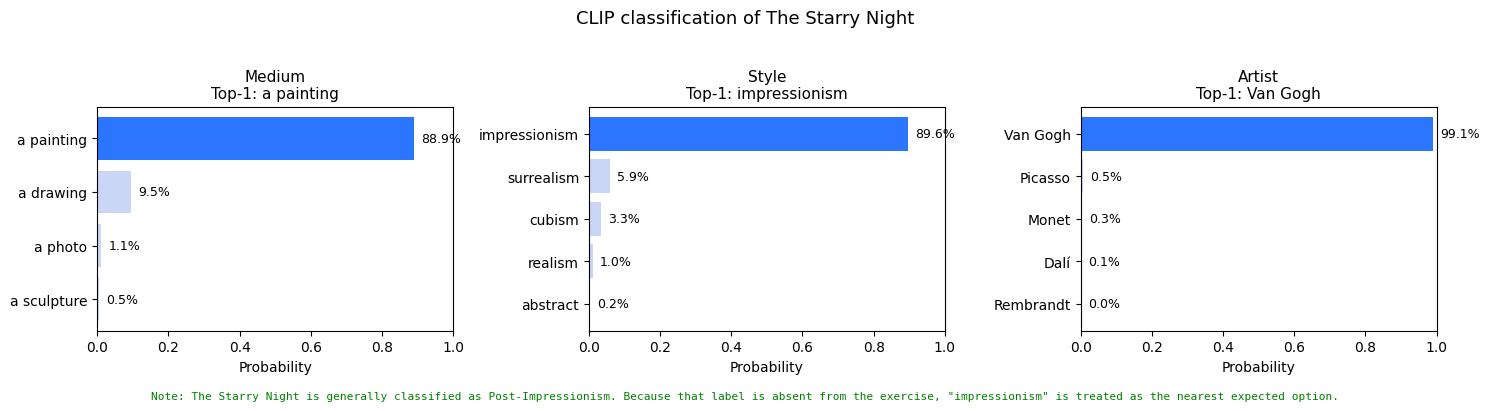

Chart saved in: /content/drive/MyDrive/TAE_IA_M6/L10_output/exercise2_clip_category_design.png


In [ ]:
# Exercise 2 -- CLIP category design
# Remember: save any images to OUTPUT_DIR, e.g. img.save(os.path.join(OUTPUT_DIR, "exercise2.png"))

import os
import torch
import matplotlib.pyplot as plt
from transformers import CLIPProcessor, CLIPModel

device = 'cuda' if torch.cuda.is_available() else 'cpu'
_clip_processor = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch32')
_clip_model     = CLIPModel.from_pretrained('openai/clip-vit-base-patch32').to(device)

def clip_classify(image, categories):
    inputs = _clip_processor(text=categories, images=image, return_tensors='pt', padding=True).to(device)
    with torch.no_grad():
        outputs = _clip_model(**inputs)
    probs = outputs.logits_per_image.softmax(dim=1)[0].cpu().numpy()
    ranked = sorted(zip(categories, probs), key=lambda x: -x[1])
    return ranked

category_sets = {
    'Medium':  ['a painting', 'a photo', 'a drawing', 'a sculpture'],
    'Style':   ['impressionism', 'cubism', 'surrealism', 'realism', 'abstract'],
    'Artist':  ['Van Gogh', 'Monet', 'Picasso', 'Rembrandt', 'Dalí'],
}

art_img = images['art']
results = {}
for label, cats in category_sets.items():
    ranked = clip_classify(art_img, cats)
    results[label] = ranked
    top1, top1_prob = ranked[0]
    print(f'[{label}] Top-1: {top1} ({top1_prob:.1%})')
    for cat, prob in ranked:
        print(f'  {cat:15s}: {prob:.1%}')
    print()

# --- Gráfica de barras horizontales por set ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('CLIP classification of The Starry Night', fontsize=13)

for ax, (label, ranked) in zip(axes, results.items()):
    cats  = [c for c, _ in ranked]
    probs = [p for _, p in ranked]
    colors = ['#2C75FF'] + ['#c9d6f5'] * (len(cats) - 1)  # top-1 resaltado
    bars = ax.barh(cats, probs, color=colors)
    ax.invert_yaxis()  # top-1 arriba
    ax.set_xlim(0, 1.0)
    ax.set_xlabel('Probability')
    ax.set_title(f'{label}\nTop-1: {cats[0]}', fontsize=11)
    for bar, p in zip(bars, probs):
        ax.text(p + 0.02, bar.get_y() + bar.get_height() / 2, f'{p:.1%}',
                 va='center', fontsize=9)

fig.text(0.5, 0.005,
          'Note: The Starry Night is generally classified as Post-Impressionism. '
          'Because that label is absent from the exercise, "impressionism" is '
          'treated as the nearest expected option.',
          ha='center', fontsize=8, color='green', family='monospace')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

out_path = os.path.join(OUTPUT_DIR, 'exercise2_clip_category_design.png')
plt.savefig(out_path, dpi=100, bbox_inches='tight')
plt.show()
print(f'Chart saved in: {out_path}')

*Which category type worked best? What principle does this suggest for designing CLIP category sets?*

(double-click to edit)

---
## Part 4 — Critical Analysis

> Required. Answer with real outputs from today's session.

**4.1 — Caption quality pattern:** rank the 8 image types from most to least accurately captioned. What property — visual complexity, abstractness, presence of text, familiarity to training data — best predicts caption quality? Support your ranking with a specific example of a caption that was accurate and one that was generic or wrong.

*Write here (reference captioning_grid.png):*
Ranking de mejor a peor (basado en captioning_grid.png):

art – "the starry night by vincent van gogh" (identificó la obra exacta)
landscape – "moraine lake, banff national park, alberta, canada" (lugar específico y correcto)
urban – "a man in a suit standing on a box in the middle of a city street" (descripción precisa de la escena)
chart – "a bar chart showing the number of sales units in the quarter" (tipo correcto, sin detalle numérico)
animal – "a cat sitting on a bed" (correcto pero genérico)
food – "a variety of food items including meat, vegetables, and fruit" (correcto pero vago)
meme – "one does not simply walk into the moor" (falla de OCR: "Mordor" → "moor")
document – "informe mercantil vendita $ 2,000" (texto incoherente, mezcla idiomas y datos inventados)

La propiedad que mejor predice la calidad es la familiaridad con los datos de entrenamiento combinada con la dependencia de OCR preciso: las imágenes icónicas/memorizadas (Starry Night, Moraine Lake) obtienen captions extremadamente específicos y correctos, mientras que las imágenes que requieren leer texto con precisión (document, meme) fallan porque BLIP-2 "alucina" texto plausible en vez de transcribirlo literalmente. Ejemplo preciso: "the starry night by vincent van gogh". Ejemplo genérico/erróneo: "informe mercantil vendita $ 2,000".



---

**4.2 — VQA failure modes:** identify two specific questions from Section 2.3 where BLIP-2 gave a confidently wrong answer. For each, describe what visual reasoning a human would use and what the model apparently lacks. Is the failure in visual perception, language understanding, or world knowledge?

*Write here (include the actual question and wrong answer from your output):*

Caso 1 (chart): Q: "Is there any text visible in this image? If so, what does it say?" → A: "Yes, there is text visible in this image. If so, what does
it say?" El modelo repite la pregunta en vez de responderla. Un humano leería directamente las etiquetas del eje/leyenda. Es un fallo de generación de lenguaje (comportamiento degenerado tipo eco), no de percepción.

Caso 2 (counting test): con 2 círculos respondió "3"; con 5, "four circles"; con 10 y con 20, ambos "6". Un humano simplemente contaría objetos discretos uno por uno. BLIP-2 se satura alrededor de 5–6 independientemente del conteo real. Es un fallo de percepción visual: el modelo no tiene un mecanismo de enumeración explícito, solo estima densidad visual aproximada.

---

**4.3 — CLIP confidence calibration:** from Section 2.4, identify one case where CLIP assigned high confidence to a wrong category. What visual or semantic property of the image caused the misclassification? Would adding more specific category descriptions (e.g., "a photo of a cat sitting on a couch" instead of "a cat") have helped?

*Write here (reference clip_confidence.png):*

Caso: la imagen document fue clasificada como "a bar chart or graph" con 65.8% de confianza, en vez de "a document with text" (solo 13.3%).

Propiedad visual/semántica causante: el documento probablemente contiene líneas, tablas o cuadrículas que visualmente se parecen a barras/ejes de un gráfico; CLIP compara embeddings de imagen contra frases de categoría genéricas sin poder "leer" el contenido textual, así que se guía por estructura de bajo nivel (líneas rectas, contraste blanco/negro) en vez de semántica textual.

Sí, categorías más específicas ayudarían: reemplazar "a document with text" por algo como "a printed invoice with rows of numbers" o "a scanned business document" le daría al encoder de texto de CLIP un anclaje semántico más cercano a la imagen real, reduciendo la ambigüedad con "a bar chart or graph".

---

**4.4 — Meme experiment:** based on Section 2.5, describe what BLIP-2 was able to perceive about the meme (text, visual elements) and what it could not understand (cultural reference, humor, intent). In one sentence, state the boundary between perception and cultural reasoning, and explain why this boundary exists given how BLIP-2 was trained.

*Write here (reference meme_experiment.png and your VQA outputs):*
BLIP-2 sí pudo percibir: la escena visual (un hombre en un camino) y transcribir aproximadamente el texto superpuesto, e incluso recuperó la referencia cultural correcta cuando se le preguntó directamente ("What is the cultural reference in this image?" → "One does not simply walk into Mordor").

Sin embargo, no pudo razonar sobre la intención humorística ni conectar esa referencia con el resto de las preguntas: a "What is the joke or humor..." respondió "The joke is that the man is walking in the middle of the road" (ignora el formato sarcástico del meme), a "Is this image funny?" respondió de forma circular ("...because it is a funny image"), y a "What movie or franchise..." respondió incoherentemente ("...walk into a movie theater"), fallando en vincular su propio acierto anterior sobre Mordor con "El Señor de los Anillos".


---
## Submission Checklist

- [ ] All cells ran from start to finish without errors
- [ ] Section 2.2: captioning grid (8 images) saved
- [ ] Section 2.3: VQA results printed for 3 images + counting test saved
- [ ] Section 2.4: CLIP top-1 predictions table printed + confidence chart saved
- [ ] Section 2.5: meme experiment captions and VQA answers printed
- [ ] Exercise 1: VQA prompt engineering with 3 phrasings
- [ ] Exercise 2: CLIP category design — 3 category sets compared
- [ ] Part 4: Critical Analysis completed (all 4 questions)

**Save:** `File > Save a copy in Drive`

> **No cleanup needed after L10.** BLIP-2 weights (~2.7 GB) remain cached — they are used again in L11 and are the foundation of final projects P1, P3, and P4.

---
## Before You Close This Tab

- [ ] Confirmed all outputs from this session are saved in `TAE_IA_M6/L10_output/` on Drive (see checklist above)
- [ ] No cleanup needed — BLIP-2 stays cached for L11 and the final projects
- [ ] Disconnected and deleted this runtime: `Runtime > Disconnect and delete runtime`

Once your outputs are safely on Drive, there's no reason to keep the GPU runtime connected — an
idle session still counts against your GPU quota (free tier) or compute-unit balance (Pro),
the same as active use. Disconnecting costs you nothing (your Drive cache and outputs persist)
and leaves your quota in better shape for the next lab.

---
*TAE-IA 2025 · Cocyten-Nayarit · Module 6 · L10*  
*Platform: Google Colab (T4 GPU) · Python 3.10*